# Nature-Based Financial Risk Analysis - Demo Walkthrough

This notebook walks through the whole package **without needing any DNB
data or Azure access** - it uses a small synthetic ("demo") portfolio
instead. If you are new to either the finance side or the Python side,
this is the place to start.

**The big picture**, in one sentence: this package estimates how much
money investors could lose if nature (pollination, water regulation, soil
retention, ...) keeps degrading, by tracing the effect through the economy
and into credit risk.

The chain of reasoning is:

1. A **scenario** assumes ecosystem services degrade by some amount (e.g. a
   10% drop in pollination).
2. Economic sectors that depend on that service (e.g. agriculture) see
   their **production** fall.
3. A lower production means a **higher probability of default (PD)** for
   companies in that sector - captured with the **Merton structural credit
   risk model**, which treats a company's equity as a call option on its
   assets and derives PD from how far asset value is from the company's
   debt (the "distance to default").
4. A higher PD means the **bonds and shares** issued by that company are
   worth less - so anyone holding them (banks, pension funds, insurers...)
   loses value.

This notebook runs that whole chain, end to end, on fictitious data.


## About the data used here

- The **instruments and their holders** (which pension fund holds which
  bond, etc.) are entirely **fictitious** - generated by
  `examples/generate_demo_data.py` with a fixed random seed, purely so this
  notebook has something to compute on. Real portfolio data (SHS/AnaCredit)
  is confidential DNB microdata and is never shipped in this repository.
- The **vulnerability scores** (how dependent is "Agriculture in France" on
  "Pollination", say) are **real, non-confidential data**, already shipped
  in `data/DS_Vuln_update/Vuln_final_store/`. They come from ENCORE,
  EXIOBASE and ND-GAIN (see `DEVELOPER_GUIDE.md` for details) and describe
  sector-country relationships, not individual companies.

So: fake portfolio, real ecosystem science. The point is to see the
*mechanism* working, not to draw conclusions about real exposure.


In [1]:
import pandas as pd
import nature_analysis

pd.set_option('display.max_columns', 12)
pd.set_option('display.width', 120)

print(f"nature_analysis version: {nature_analysis.__version__}")


nature_analysis version: 2.0.0


## Step 1 - Look at the (fictitious) portfolio

Before running anything, let's look at what a "portfolio" looks like to
this package: a table of financial instruments (bonds `F_32` and listed
shares `F_511`), each with a probability of default (`pd`), a price
volatility (`vol`), an issuer country and sector (NACE code), and - for
bonds - a residual maturity.


In [2]:
from nature_analysis import data_loader

instruments = data_loader.load_demo_shs_data()
holders = data_loader.load_demo_shs_holder_data()

print(f"{len(instruments)} fictitious instruments, held by {len(holders)} (instrument, holder) records")
instruments.head()


300 fictitious instruments, held by 579 (instrument, holder) records


,PERIOD,IDENTIFIER,INSTR_CLASS,ISSUER_COUNTRY,pd,vol,debt_ratio,nace_lvl4,nace_lvl2,nace_lvl,resid_mat_yr
0,2024-Q4,DEMO000000,F_511,JP,0.0260,0.325,0.666,NaN,60,2,NaN
1,2024-Q4,DEMO000001,F_511,US,0.0301,0.188,0.690,NaN,2,2,NaN
2,2024-Q4,DEMO000002,F_32,NL,0.0180,0.419,0.235,NaN,29,2,9.0
3,2024-Q4,DEMO000003,F_511,PT,0.0285,0.414,0.269,NaN,50,2,NaN
4,2024-Q4,DEMO000004,F_32,AT,0.0607,0.311,0.595,NaN,60,2,13.0


Each instrument is also held by one or more institutions (`holders`),
which is what lets the final results be broken down by *who* is exposed -
pension funds, insurers, banks, households, government - not just by
sector.


In [3]:
holders.head()


,IDENTIFIER,HOLDER_SECTOR,HOLDER_AREA,OBS_VALUE
0,DEMO000000,Government,BE,23912311.60
1,DEMO000000,Investment Funds,NL,24766295.22
2,DEMO000000,Households,FR,20427383.15
3,DEMO000001,Investment Funds,FR,27652918.89
4,DEMO000002,Government,FR,39670948.45


## Step 2 - Run the full analysis

`nature_analysis.run_demo()` does everything in one call:
load the data -> compute how much each instrument's issuer is affected by
each ecosystem-service scenario -> convert that into a PD/price shock via
the Merton model -> aggregate losses by holder.

(Pass `n_instruments=` for an even faster run while you're experimenting.)


In [4]:
import logging
logging.getLogger('nature_analysis').setLevel(logging.WARNING)  # quiet the progress logs below


In [5]:
%%time
results = nature_analysis.run_demo()
print(f"{len(results):,} result rows "
      f"({results['scenario'].nunique()} scenarios x "
      f"{results['eco_service'].nunique()} ecosystem services)")


11,220 result rows (4 scenarios x 5 ecosystem services)
CPU times: user 7.05 s, sys: 5.67 s, total: 12.7 s
Wall time: 23.4 s


## Step 3 - Look at the results

Each row is a (holder sector, holder country, instrument type, issuer
sector/country, ecosystem service, scenario) combination, with the
resulting **portfolio value loss** (`VALUE_LOSS`, in EUR) against the
original portfolio value (`OBS_VALUE`).


In [6]:
results[['HOLDER_SECTOR', 'HOLDER_AREA', 'nace_lvl1', 'scenario',
         'eco_service', 'OBS_VALUE', 'VALUE_LOSS', 'loss_perc']].head(10)


,HOLDER_SECTOR,HOLDER_AREA,nace_lvl1,scenario,eco_service,OBS_VALUE,VALUE_LOSS,loss_perc
0,Financial Corporations,BE,A,0_World_shock_10perc_02_GOVonNFC,Pollination,14717501.73,-9.301967e+06,-0.632034
1,Financial Corporations,BE,K,0_World_shock_10perc_02_GOVonNFC,Pollination,3795478.40,-2.279063e+03,-0.000600
2,Financial Corporations,BE,P,0_World_shock_10perc_02_GOVonNFC,Pollination,11953030.04,-8.291776e+05,-0.069370
3,Financial Corporations,BE,A,0_World_shock_10perc_02_GOVonNFC,Pollination,55236489.36,-4.059847e+07,-0.734994
4,Financial Corporations,BE,A,0_World_shock_10perc_02_GOVonNFC,Pollination,23796354.14,-1.083676e+07,-0.455396
5,Financial Corporations,BE,K,0_World_shock_10perc_02_GOVonNFC,Pollination,2339528.09,-3.593691e+04,-0.015361
6,Financial Corporations,BE,H,0_World_shock_10perc_02_GOVonNFC,Pollination,38398620.06,-4.026122e+05,-0.010485
7,Financial Corporations,BE,M,0_World_shock_10perc_02_GOVonNFC,Pollination,16457605.26,-4.481553e+06,-0.272309
8,Financial Corporations,BE,M,0_World_shock_10perc_02_GOVonNFC,Pollination,7854316.25,-3.077896e+06,-0.391873
9,Financial Corporations,BE,A,0_World_shock_10perc_02_GOVonNFC,Pollination,12954869.55,-6.125786e+06,-0.472856


In [7]:
total_value = results['OBS_VALUE'].sum()
total_loss = results['VALUE_LOSS'].sum()
print(f"Total (fictitious) portfolio value: EUR {total_value:,.0f}")
print(f"Total (fictitious) value loss:      EUR {total_loss:,.0f}")
print(f"Overall loss rate:                  {100 * total_loss / total_value:.2f}%")


Total (fictitious) portfolio value: EUR 289,289,339,421
Total (fictitious) value loss:      EUR -26,756,776,286
Overall loss rate:                  -9.25%


## Step 4 - Which sectors are most exposed?

`nace_lvl1` is the top-level NACE economic sector of the instrument's
*issuer* (not the holder). We'd expect sectors that depend heavily on
nature - agriculture, forestry, fishing - to show larger average losses
than, say, insurance or business services.


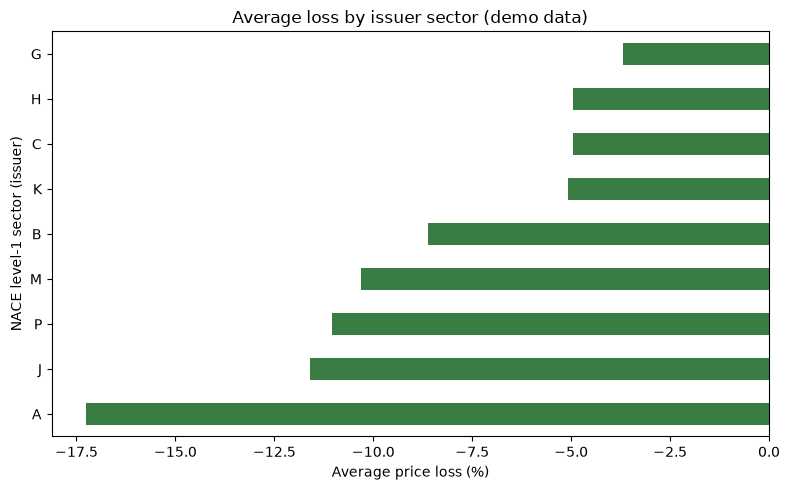

In [8]:
import matplotlib.pyplot as plt

by_sector = (
    results.groupby('nace_lvl1')['loss_perc']
    .mean()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8, 5))
by_sector.mul(100).plot.barh(ax=ax, color='#3a7d44')
ax.set_xlabel('Average price loss (%)')
ax.set_ylabel('NACE level-1 sector (issuer)')
ax.set_title('Average loss by issuer sector (demo data)')
plt.tight_layout()
plt.show()


`A` (Agriculture, forestry and fishing) coming out on top is exactly the
package's core message: sectors most dependent on nature are also the ones
most exposed to its degradation, once that dependency is priced into
credit risk.


## Step 5 - Which ecosystem service matters most?

Different scenarios shock different ecosystem services by different
amounts. We can compare their average effect across all instruments.


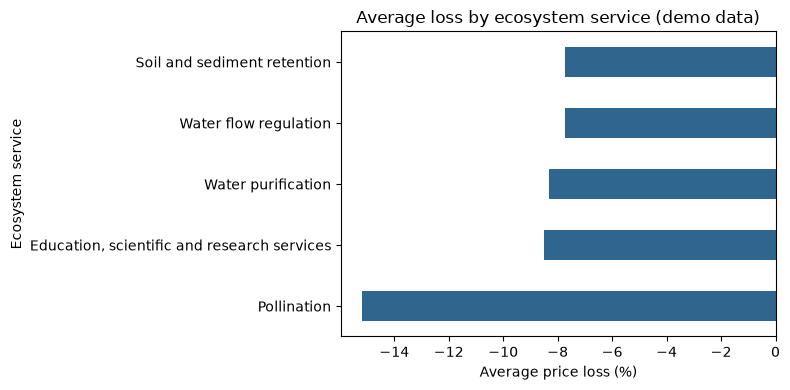

In [9]:
by_service = (
    results.groupby('eco_service')['loss_perc']
    .mean()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8, 4))
by_service.mul(100).plot.barh(ax=ax, color='#2f6690')
ax.set_xlabel('Average price loss (%)')
ax.set_ylabel('Ecosystem service')
ax.set_title('Average loss by ecosystem service (demo data)')
plt.tight_layout()
plt.show()


## Where to go from here

- **Use real data (DNB only):** replace `run_demo()` with `run_pipeline()`
  or `run_quick_test()` - same output shape, real SHS instruments loaded
  through Azure. See the main [README](../README.md#quick-start).
- **Try a different scenario:** scenarios and ecosystem services come from
  `data/DS_Vuln_update/Vuln_final_store/Final_Vuln_file.csv`. Add a new
  scenario config under `data/DS_Vuln_update/config_store/` and call
  `nature_analysis.regenerate_vulnerability_files()` to add it.
- **Regenerate this demo dataset:**
  `python examples/generate_demo_data.py` (deterministic, fixed seed).
- **Understand the Merton model:** see `nature_analysis/financial.py` and
  the "Financial Models" section of the README.
